# Exploratory Data Analysis (EDA)
## The Economic Aftershocks: Analyzing the Impact of Major Earthquakes on National Recovery

**Author:** Betül Merey (33963)
**Course:** DSA 210 — Introduction to Data Science
**Institution:** Sabancı University

---

This notebook explores the merged earthquake-economy dataset to understand:
- How earthquake magnitude relates to economic damage
- Whether a country's income level affects its economic vulnerability
- General patterns in the data before formal hypothesis testing




---
In this project, direct economic damage (USD, inflation-adjusted) was chosen as the primary dependent variable instead of annual GDP growth. Annual growth often masks the immediate impact of earthquakes because:

- Reconstruction Effect: Increased government and private spending for rebuilding can paradoxically boost GDP shortly after a disaster.

- Timing Sensitivity: Shocks occurring late in the fiscal year show minimal impact on that year's annual data.
For vulnerability analysis (Q2), we used damage normalized by GDP per capita to better capture the relative economic burden on citizens.

---
**Data source:** EM-DAT + World Bank (merged in `01_data_merging.ipynb`)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/DSA210_PROJ')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# color palette for income groups — used consistently across all plots
INCOME_ORDER = ["Low", "Lower-Middle", "Upper-Middle", "High"]
PALETTE = {
    "Low"          : "#d62728",
    "Lower-Middle" : "#ff7f0e",
    "Upper-Middle" : "#2ca02c",
    "High"         : "#1f77b4"
}

print("Libraries loaded.")

Libraries loaded.


## 1. Load & Prepare Data

In [ ]:
df = pd.read_csv('data/processed/merged_dataset.csv')

# set income_group as an ordered category so plots sort correctly
df["income_group"] = pd.Categorical(
    df["income_group"],
    categories=INCOME_ORDER,
    ordered=True
)

# Q1 metric: log10 of adjusted damage
# we use log scale because damage values span many orders of magnitude
df["log_damage"] = np.where(
    df["total_damage_adj_kUSD"] > 0,
    np.log10(df["total_damage_adj_kUSD"]),
    np.nan
)

# Q2 metric: damage relative to country's GDP per capita
# this captures how heavy the economic burden was relative to the country's wealth
df["damage_ratio"] = df["total_damage_adj_kUSD"] / df["gdp_per_capita_event_year"]

print(f"Dataset: {len(df)} rows × {len(df.columns)} columns")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print(f"Countries: {df['iso3'].nunique()}")
df.head()

Dataset: 1918 rows × 17 columns
Year range: 1990.0 – 2026.0
Countries: 110


,iso3,country,year,magnitude,total_deaths,total_affected,total_damage_kUSD,total_damage_adj_kUSD,pre_event_avg_gdp,gdp_event_year,gdp_drop,recovery_years,gdp_per_capita_event_year,unemployment_event_year,income_group,log_damage,damage_ratio
0,PHL,Philippines,1990.0,6.6,1.0,34504.0,900.0,2161.0,NaN,NaN,NaN,NaN,803.572588,NaN,Low,3.334655,2.689241
1,IDN,Indonesia,1990.0,7.8,5.0,7036.0,NaN,NaN,NaN,NaN,NaN,NaN,578.420121,NaN,Low,NaN,NaN
2,BGR,Bulgaria,1990.0,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2366.529821,NaN,Lower-Middle,NaN,NaN
3,ROU,Romania,1990.0,7.0,9.0,700.0,NaN,NaN,NaN,NaN,NaN,NaN,1648.485230,NaN,Lower-Middle,NaN,NaN
4,SUN,Soviet Union,1990.0,7.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Descriptive Statistics

Before plotting, we look at the basic summary statistics for our key variables.

In [ ]:
cols = ["magnitude", "total_deaths", "total_damage_adj_kUSD",
        "log_damage", "damage_ratio",
        "gdp_per_capita_event_year", "unemployment_event_year"]

# keep only columns that exist in our dataset
cols = [c for c in cols if c in df.columns]

df[cols].describe().round(3)

,magnitude,total_deaths,total_damage_adj_kUSD,log_damage,damage_ratio,gdp_per_capita_event_year,unemployment_event_year
count,952.000,631.000,3.960000e+02,396.000,379.000,889.000,892.000
mean,6.233,1426.071,3.277974e+06,5.077,491.422,7343.256,6.604
std,0.953,12405.877,1.979187e+07,1.163,2245.165,11186.824,4.230
min,3.200,1.000,3.000000e+00,0.477,0.000,22.952,0.423
25%,5.600,2.000,2.079550e+04,4.318,4.844,1140.590,3.610
50%,6.200,7.000,1.309315e+05,5.117,25.884,3093.489,4.980
75%,6.825,40.000,6.479528e+05,5.811,136.987,7331.854,8.720
max,9.100,222570.000,2.928555e+08,8.467,35148.094,82138.789,28.575


In [ ]:
# number of events per income group
print("Events per income group:")
print(df["income_group"].value_counts().sort_index())

# missing values — important to know before analysis
print("\nMissing values:")
print(df[cols].isna().sum())

Events per income group:
income_group
Low             207
Lower-Middle    327
Upper-Middle    233
High            122
Name: count, dtype: int64

Missing values:
magnitude                     966
total_deaths                 1287
total_damage_adj_kUSD        1522
log_damage                   1522
damage_ratio                 1539
gdp_per_capita_event_year    1029
unemployment_event_year      1026
dtype: int64


In [ ]:
# median damage ratio per income group for M >= 6.0 earthquakes
sub = df[
    (df["magnitude"] >= 6.0) &
    df["damage_ratio"].notna() &
    (df["damage_ratio"] > 0)
]

print("Median damage ratio by income group (M ≥ 6.0 only):")
sub.groupby("income_group", observed=True)["damage_ratio"] \
   .agg(["median", "mean", "count"]) \
   .round(2)

Median damage ratio by income group (M ≥ 6.0 only):


,median,mean,count
income_group,,,
Low,135.83,1105.68,47
Lower-Middle,45.88,972.56,94
Upper-Middle,41.48,166.63,59
High,16.99,386.00,57


## 3. Earthquake Magnitude Distribution

We look at how magnitudes are distributed overall and across income groups.
Most events in EM-DAT are M ≥ 5.0 since smaller earthquakes rarely cause
significant damage or casualties.

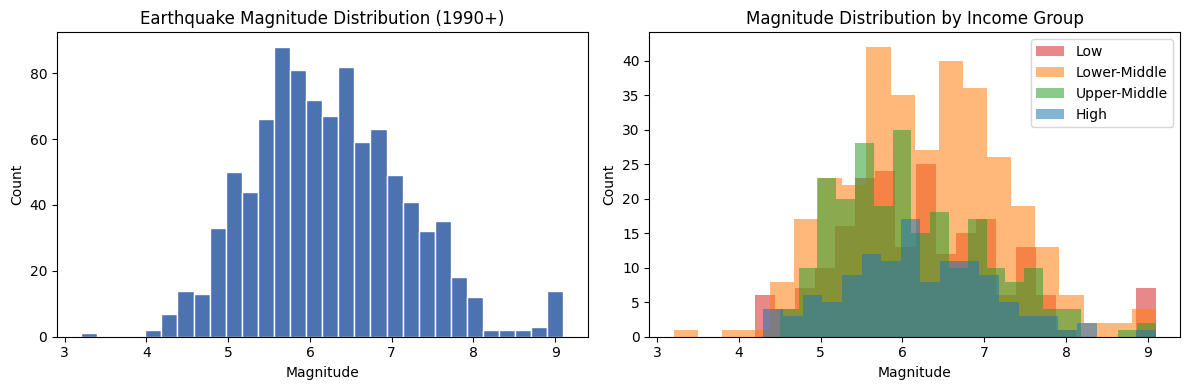

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left plot: overall magnitude distribution
axes[0].hist(df["magnitude"].dropna(), bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Count")
axes[0].set_title("Earthquake Magnitude Distribution (1990+)")

# right plot: magnitude distribution split by income group
for grp in INCOME_ORDER:
    sub = df[df["income_group"] == grp]["magnitude"].dropna()
    if len(sub):
        axes[1].hist(sub, bins=20, alpha=0.55, label=grp, color=PALETTE[grp])

axes[1].set_xlabel("Magnitude")
axes[1].set_ylabel("Count")
axes[1].set_title("Magnitude Distribution by Income Group")
axes[1].legend()

plt.tight_layout()
plt.savefig('02_EDA/outputs/figures/01EDA_magnitude_distribution.png', dpi=150)
plt.show()

## 4. Economic Damage Distribution

Economic damage values span a huge range (thousands to trillions of USD),
so we use log₁₀ scale to make the distribution readable.

We also plot magnitude vs. log(damage) to get an early visual sense of
whether larger earthquakes tend to cause more economic damage (H1).

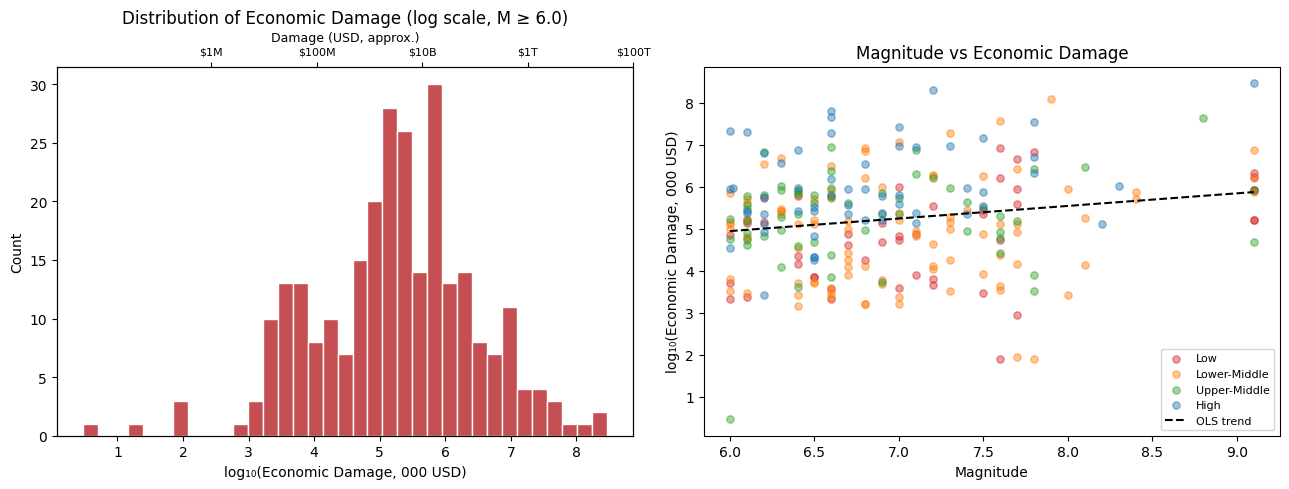

In [ ]:
# filter: M >= 6.0 and damage is recorded
sub = df[(df["magnitude"] >= 6.0)].dropna(subset=["log_damage"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: histogram of log damage
axes[0].hist(sub["log_damage"], bins=35, color="#c44e52", edgecolor="white")
axes[0].set_xlabel("log₁₀(Economic Damage, 000 USD)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Economic Damage (log scale, M ≥ 6.0)")

# add a second x-axis on top showing real USD values for reference
ax2 = axes[0].twiny()
ax2.set_xlim(axes[0].get_xlim())
ax2.set_xticks([3, 5, 7, 9, 11])
ax2.set_xticklabels(["$1M", "$100M", "$10B", "$1T", "$100T"], fontsize=8)
ax2.set_xlabel("Damage (USD, approx.)", fontsize=9)

# right: scatter plot of magnitude vs log damage, colored by income group
for grp in INCOME_ORDER:
    g = sub[sub["income_group"] == grp]
    if g.empty:
        continue
    axes[1].scatter(g["magnitude"], g["log_damage"],
                    alpha=0.45, s=28, label=grp, color=PALETTE[grp])

# add OLS trend line to see general direction
m, b = np.polyfit(sub["magnitude"], sub["log_damage"], 1)
xs = np.linspace(sub["magnitude"].min(), sub["magnitude"].max(), 100)
axes[1].plot(xs, m * xs + b, color="black", linewidth=1.5,
             linestyle="--", label="OLS trend")

axes[1].set_xlabel("Magnitude")
axes[1].set_ylabel("log₁₀(Economic Damage, 000 USD)")
axes[1].set_title("Magnitude vs Economic Damage")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('02_EDA/outputs/figures/02EDA_damage_distribution.png', dpi=150)
plt.show()

## 5. Economic Vulnerability by Income Group

Here we look at the damage ratio (damage / GDP per capita) across income groups.
This metric captures the *relative* burden of an earthquake — a country with
low GDP per capita suffers more economically even from the same absolute damage.

We use log scale on the y-axis because the distribution is heavily right-skewed.

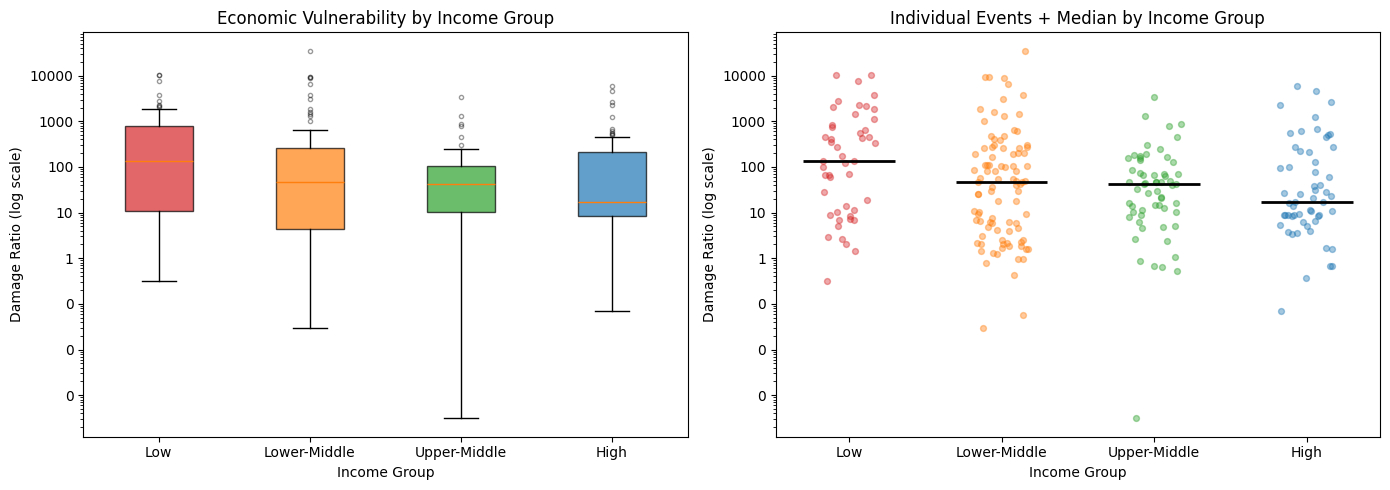

In [ ]:
sub = df[
    (df["magnitude"] >= 6.0) &
    df["damage_ratio"].notna() &
    (df["damage_ratio"] > 0)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: boxplot per income group
groups_present = [g for g in INCOME_ORDER if g in sub["income_group"].values]
data_by_group  = [sub[sub["income_group"] == g]["damage_ratio"].values for g in groups_present]

bp = axes[0].boxplot(data_by_group, tick_labels=groups_present,
                     patch_artist=True,
                     flierprops=dict(marker="o", markersize=3, alpha=0.4, linestyle="none"))

for patch, lbl in zip(bp["boxes"], groups_present):
    patch.set_facecolor(PALETTE[lbl])
    patch.set_alpha(0.7)

axes[0].set_yscale("log")
axes[0].set_xlabel("Income Group")
axes[0].set_ylabel("Damage Ratio (log scale)")
axes[0].set_title("Economic Vulnerability by Income Group")
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter())

# right: strip plot showing every individual event
np.random.seed(42)
x_positions = {g: i for i, g in enumerate(groups_present)}

for grp in groups_present:
    vals = sub[sub["income_group"] == grp]["damage_ratio"].values
    # add small random jitter on x so points don't stack on top of each other
    jitter = np.random.uniform(-0.18, 0.18, size=len(vals))
    axes[1].scatter(np.full(len(vals), x_positions[grp]) + jitter,
                    vals, alpha=0.4, s=18, color=PALETTE[grp])
    # draw a thick black line at the median
    med = np.median(vals)
    axes[1].hlines(med, x_positions[grp] - 0.3, x_positions[grp] + 0.3,
                   colors="black", linewidth=2)

axes[1].set_yscale("log")
axes[1].set_xticks(range(len(groups_present)))
axes[1].set_xticklabels(groups_present)
axes[1].set_xlabel("Income Group")
axes[1].set_ylabel("Damage Ratio (log scale)")
axes[1].set_title("Individual Events + Median by Income Group")
axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.savefig('02_EDA/outputs/figures/03EDA_damage_ratio_by_income.png', dpi=150)
plt.show()

## 6. GDP per Capita Distribution

Since we use GDP per capita to classify countries into income groups,
it's worth checking how this variable is distributed in our dataset.

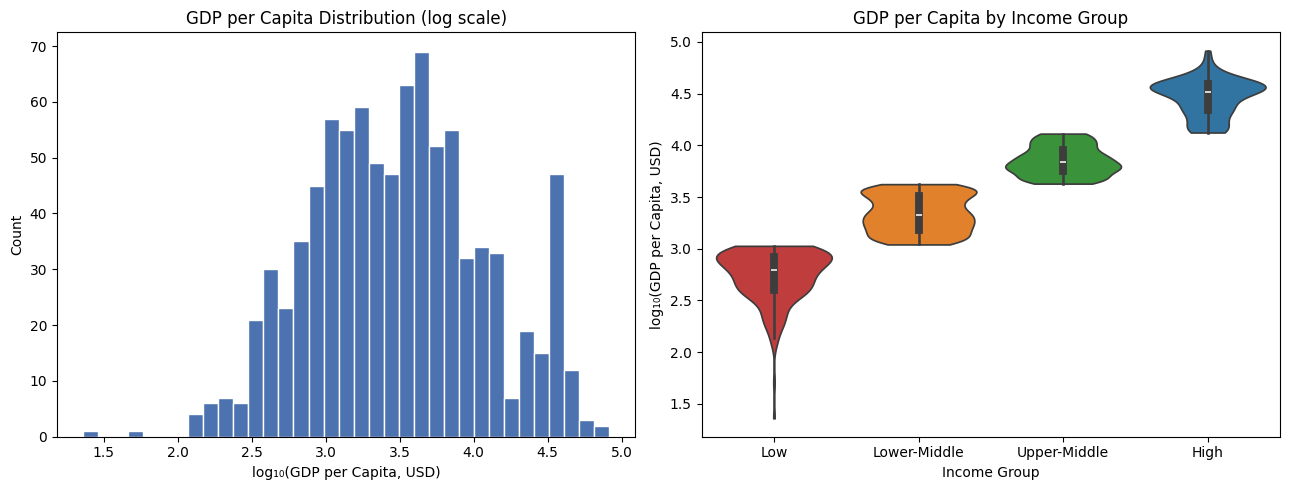

In [ ]:
sub = df.dropna(subset=["gdp_per_capita_event_year", "income_group"]).copy()
sub["log_gdp_pc"] = np.log10(sub["gdp_per_capita_event_year"].clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: overall histogram
axes[0].hist(sub["log_gdp_pc"], bins=35, color="#4c72b0", edgecolor="white")
axes[0].set_xlabel("log₁₀(GDP per Capita, USD)")
axes[0].set_ylabel("Count")
axes[0].set_title("GDP per Capita Distribution (log scale)")

# right: violin plot by income group
sns.violinplot(data=sub, x="income_group", y="log_gdp_pc",
               order=INCOME_ORDER, hue="income_group", palette=PALETTE,
               legend=False, inner="box", ax=axes[1], cut=0)
axes[1].set_xlabel("Income Group")
axes[1].set_ylabel("log₁₀(GDP per Capita, USD)")
axes[1].set_title("GDP per Capita by Income Group")

plt.tight_layout()
plt.savefig('02_EDA/outputs/figures/04EDA_gdp_per_capita.png', dpi=150)
plt.show()

## 7. Spearman Correlation Heatmap

We compute Spearman correlations (rank-based, robust to outliers) between
all key numeric variables. This gives an early view of which variables
move together before running formal tests.

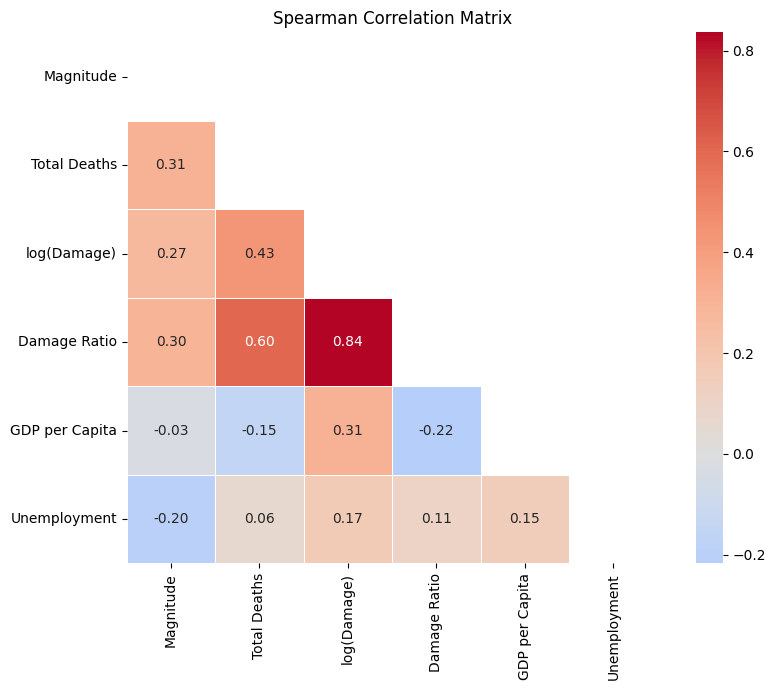

In [ ]:
cols = ["magnitude", "total_deaths", "log_damage", "damage_ratio",
        "gdp_per_capita_event_year", "unemployment_event_year"]
cols = [c for c in cols if c in df.columns]

# rename columns for cleaner labels in the plot
labels = {
    "magnitude"                : "Magnitude",
    "total_deaths"             : "Total Deaths",
    "log_damage"               : "log(Damage)",
    "damage_ratio"             : "Damage Ratio",
    "gdp_per_capita_event_year": "GDP per Capita",
    "unemployment_event_year"  : "Unemployment",
}

corr = df[cols].corr(method="spearman").rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(9, 7))

# mask the upper triangle to avoid showing duplicate values
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title("Spearman Correlation Matrix")

plt.tight_layout()
plt.savefig('02_EDA/outputs/figures/05EDA_correlation_heatmap.png', dpi=150)
plt.show()

## 8. Earthquake Events Over Time

A quick look at how many significant earthquake events were recorded per year.

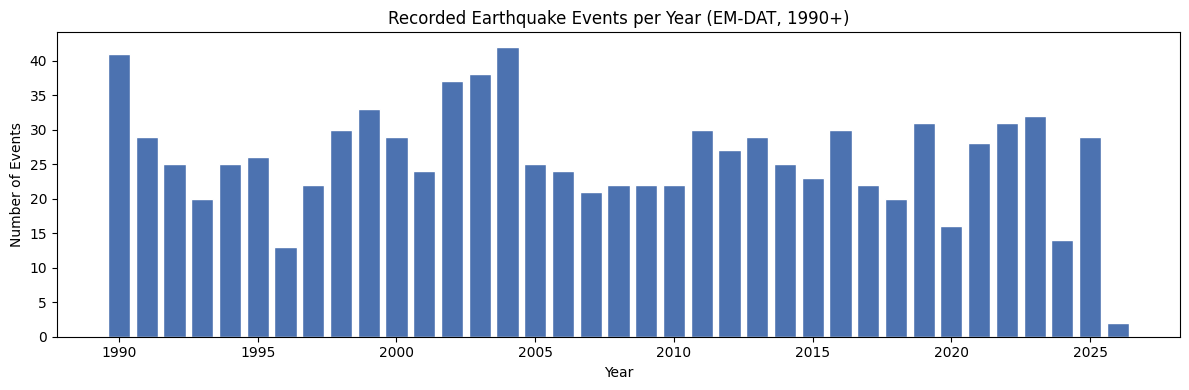

In [ ]:
yearly = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yearly.index, yearly.values, color="#4c72b0", edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Events")
ax.set_title("Recorded Earthquake Events per Year (EM-DAT, 1990+)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('02_EDA/outputs/figures/06EDA_events_over_time.png', dpi=150)
plt.show()

## 9. Top 15 Most Economically Damaging Earthquakes

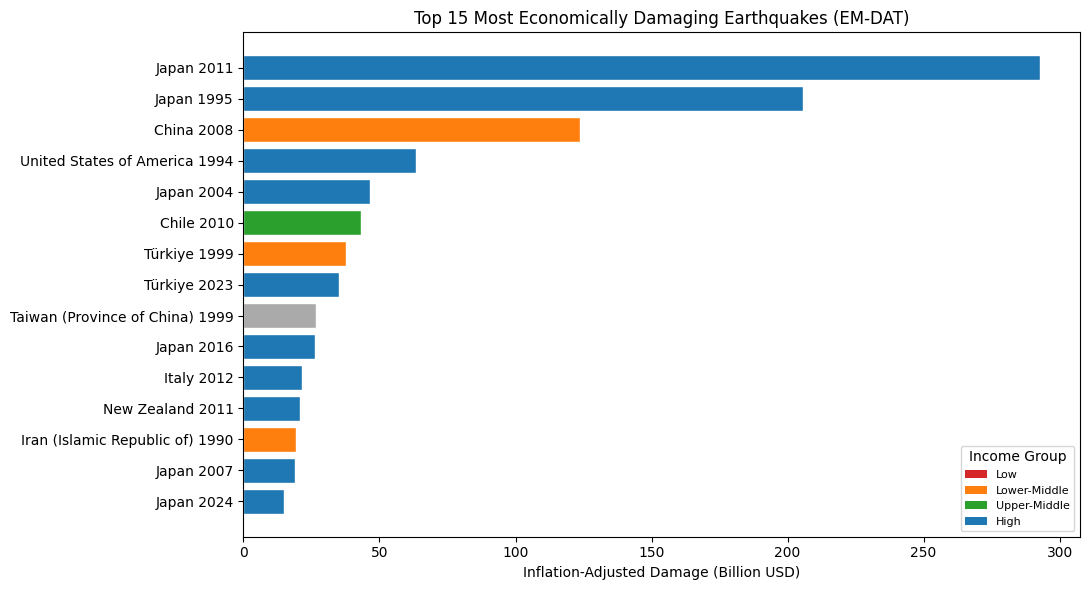

In [ ]:
top15 = df.dropna(subset=["total_damage_adj_kUSD"]) \
          .nlargest(15, "total_damage_adj_kUSD").copy()

top15["label"]    = top15["country"] + " " + top15["year"].astype(int).astype(str)
top15["damage_B"] = top15["total_damage_adj_kUSD"] / 1_000_000  # convert to billions USD
colors = [PALETTE.get(g, "#aaaaaa") for g in top15["income_group"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top15["label"], top15["damage_B"], color=colors, edgecolor="white")
ax.set_xlabel("Inflation-Adjusted Damage (Billion USD)")
ax.set_title("Top 15 Most Economically Damaging Earthquakes (EM-DAT)")
ax.invert_yaxis()

# legend showing which color = which income group
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[g], label=g) for g in INCOME_ORDER]
ax.legend(handles=legend_elements, title="Income Group", loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig('02_EDA/outputs/figures/07EDA_top15_damaging_events.png', dpi=150)
plt.show()

## 10. Key Takeaways from EDA

- **Magnitude vs damage**: The scatter plot suggests a positive trend —
  larger earthquakes tend to cause more economic damage, though there is
  considerable variance. This motivates H1.

- **Income group differences**: Low and Lower-Middle income countries show
  higher damage ratios, suggesting greater relative vulnerability. This
  motivates H2.

- **Correlation matrix**: Magnitude has a moderate positive correlation
  with log(damage). GDP per capita is negatively correlated with damage ratio,
  confirming that wealthier countries absorb economic shocks more easily.

These patterns will be formally tested in `03_hypothesis_testing.ipynb`.

---

## AI Usage Statement

AI assistance (Claude by Anthropic) was used in this notebook in the following ways:

- **Variable design**: AI explained why `damage_ratio` (damage / GDP per capita) is a better vulnerability metric than raw damage in USD, as it accounts for country wealth differences.
- **Visualization choices**: AI suggested using log scale for damage distribution and combining boxplot with strip plot for the income group comparison to show both summary statistics and individual events.
- **Correlation analysis**: AI clarified why Spearman correlation is more appropriate than Pearson for variables with extreme outliers such as `total_deaths` and `damage_ratio`.
- **Code suggestions**: Syntax help for `seaborn` violin plots and the dual x-axis on the damage histogram.

The choice of which variables to explore, which income group thresholds to use, and all written interpretations in the takeaways section were decided by the author.